In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/road.jpg')
if img is None:
    print("❌ 没读到图!检查:图叫 road.jpg 吗?在 images/ 里吗?")
else:
    print("✅ 读到了,shape:", img.shape)

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray,(5,5),0)
edges = cv2.Canny(blur,50,150)
print("edges shape:",edges.shape)


✅ 读到了,shape: (1080, 1440, 3)
edges shape: (1080, 1440)


In [19]:
h,w = edges.shape
mask = np.zeros_like(edges)

vertices = np.array([[
    (0, int(0.9 * h)),
    (int(0.45 * w), int(0.5 * h)),
    (int(0.65 * w), int(0.5 * h)),
    (w, int(0.9 * h))
]],dtype=np.int32)

cv2.fillPoly(mask,vertices,255)
masked_edges = cv2.bitwise_and(edges, mask)

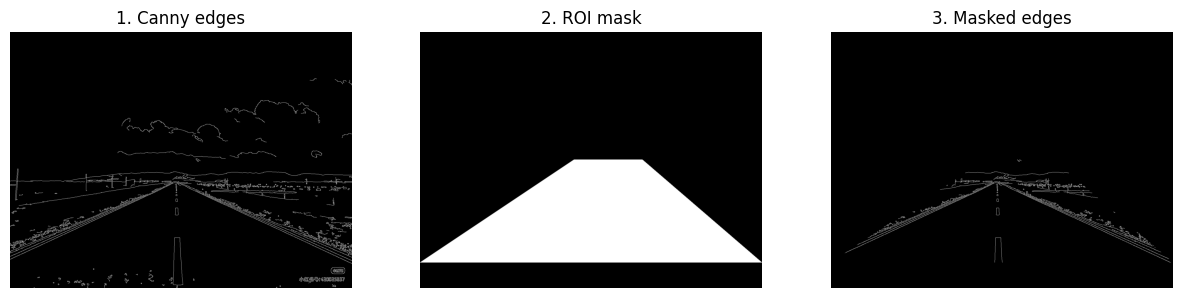

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(edges, cmap='gray');        axes[0].set_title('1. Canny edges')
axes[1].imshow(mask, cmap='gray');         axes[1].set_title('2. ROI mask')
axes[2].imshow(masked_edges, cmap='gray'); axes[2].set_title('3. Masked edges')
for ax in axes:
    ax.axis('off')
plt.show()

In [21]:
lines = cv2.HoughLinesP(masked_edges, 1, np.pi/180,
                        threshold=50, minLineLength=50, maxLineGap=100)
left_lines = []
right_lines = []

for line in lines:
    x1, y1, x2, y2 = line[0]
    if x2 - x1 == 0:          # 竖直线, 斜率无穷大, 跳过防除零
        continue
    slope = (y2 - y1) / (x2 - x1)
    if slope < -0.2:          # 负 → 左车道
        left_lines.append(line[0])
    elif slope > 0.2:         # 正 → 右车道
        right_lines.append(line[0])
    # |slope| < 0.2 接近水平, 多是噪声, 丢弃

In [22]:
def average_line(lines_group, img_height):
    if len(lines_group) == 0:
        return None
    xs, ys = [], []
    for x1, y1, x2, y2 in lines_group:
        xs += [x1, x2]
        ys += [y1, y2]
    k, b = np.polyfit(xs, ys, 1)      # 拟合直线 y = k*x + b
    y1 = img_height                    # 从图像底部
    y2 = int(img_height * 0.6)         # 到画面中部
    x1 = int((y1 - b) / k)             # 由 y=kx+b 反解 x
    x2 = int((y2 - b) / k)
    return (x1, y1, x2, y2)

In [23]:
def draw_lanes(img, left, right):
    line_img = np.zeros_like(img)      # 同大小黑布(三通道, 画彩色线)
    for lane in [left, right]:
        if lane is not None:
            x1, y1, x2, y2 = lane
            cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 8)
    result = cv2.addWeighted(img, 0.8, line_img, 1.0, 0)
    return result

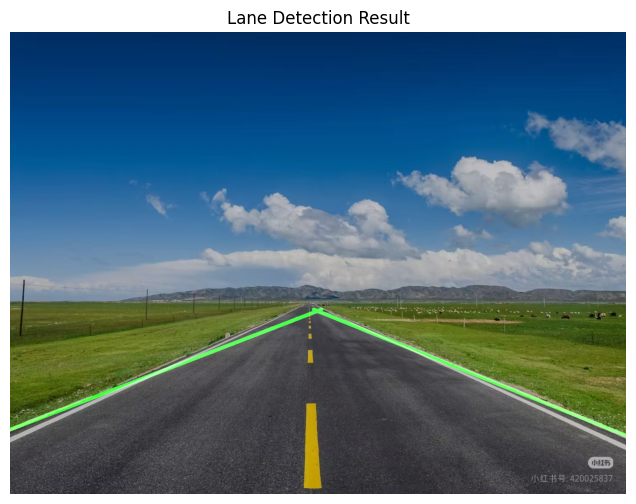

In [24]:
h_img = img.shape[0]
left = average_line(left_lines, h_img)
right = average_line(right_lines, h_img)
result = draw_lanes(img, left, right)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Lane Detection Result')
plt.axis('off')
plt.show()

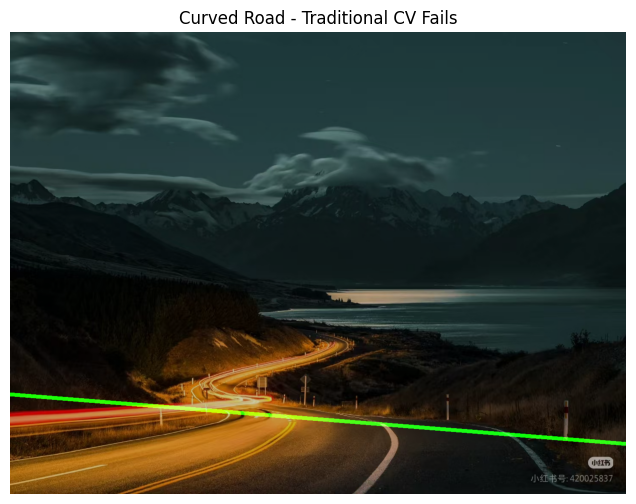

In [25]:
# ===== 弯道崩塌测试:换 curve.jpg,跑同一套流程 =====
img2 = cv2.imread('images/curve.jpg')
if img2 is None:
    print("❌ 没读到 curve.jpg")

gray2  = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
blur2  = cv2.GaussianBlur(gray2, (5, 5), 0)
edges2 = cv2.Canny(blur2, 50, 150)

h2, w2 = edges2.shape
mask2 = np.zeros_like(edges2)
vertices2 = np.array([[
    (int(0.1 * w2), h2),
    (int(0.45 * w2), int(0.6 * h2)),
    (int(0.55 * w2), int(0.6 * h2)),
    (int(0.9 * w2), h2)
]], dtype=np.int32)
cv2.fillPoly(mask2, vertices2, 255)
masked2 = cv2.bitwise_and(edges2, mask2)

lines2 = cv2.HoughLinesP(masked2, 1, np.pi/180,
                         threshold=50, minLineLength=50, maxLineGap=100)

left2, right2 = [], []
if lines2 is not None:
    for line in lines2:
        x1, y1, x2, y2 = line[0]
        if x2 - x1 == 0:
            continue
        slope = (y2 - y1) / (x2 - x1)
        if slope < -0.5:
            left2.append(line[0])
        elif slope > 0.5:
            right2.append(line[0])

left_lane2  = average_line(left2, img2.shape[0])
right_lane2 = average_line(right2, img2.shape[0])
result2 = draw_lanes(img2, left_lane2, right_lane2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(result2, cv2.COLOR_BGR2RGB))
plt.title('Curved Road - Traditional CV Fails')
plt.axis('off')
plt.show()